In [1]:
!nvidia-smi

Thu Jun  4 17:12:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.91                 Driver Version: 591.91         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P8              3W /   95W |       0MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

def check_cuda():
    print("=== PyTorch CUDA Diagnostic ===\n")

    # 1. Is CUDA available?
    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")

    # 2. PyTorch build info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA version (torch): {torch.version.cuda}")

    if not cuda_available:
        print("\n[FAIL] CUDA is not available.")
        return

    # 3. GPU details
    device_count = torch.cuda.device_count()
    print(f"\nNumber of GPUs: {device_count}")

    for i in range(device_count):
        print(f"\n--- GPU {i} ---")
        print(f"Name: {torch.cuda.get_device_name(i)}")
        print(f"Capability: {torch.cuda.get_device_capability(i)}")
        print(f"Memory Allocated: {torch.cuda.memory_allocated(i)} bytes")
        print(f"Memory Reserved: {torch.cuda.memory_reserved(i)} bytes")

    # 4. Actual computation test (this is the only *real* proof)
    try:
        device = torch.device("cuda:0")
        x = torch.rand(3, 3).to(device)
        y = torch.rand(3, 3).to(device)
        z = x @ y

        print("\n[OK] Tensor computation on GPU succeeded.")
        print(f"Result device: {z.device}")

    except Exception as e:
        print("\n[FAIL] CUDA exists but computation failed.")
        print(f"Error: {e}")


if __name__ == "__main__":
    check_cuda()

=== PyTorch CUDA Diagnostic ===

CUDA available: True
PyTorch version: 2.12.0.dev20260324+cu128
CUDA version (torch): 12.8

Number of GPUs: 1

--- GPU 0 ---
Name: NVIDIA GeForce RTX 5060 Laptop GPU
Capability: (12, 0)
Memory Allocated: 0 bytes
Memory Reserved: 0 bytes

[OK] Tensor computation on GPU succeeded.
Result device: cuda:0


## Dataset Unzip

In [3]:
from pathlib import Path
import zipfile

# Paths
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH_ZIP = DATA_DIR / "Male_and_female.zip"
EXTRACT_DIR = DATA_DIR / "Male_and_female"

In [4]:
# Unzip
with zipfile.ZipFile(DATASET_PATH_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Extracted to: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female


## Roboflow Dataset Inspection

In [ ]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_TEST_PATH = DATA_DIR / "Male_and_female"

In [ ]:
import os
os.listdir(DATASET_TEST_PATH)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

In [ ]:
DATASET_PATH_YAML = DATASET_TEST_PATH / "data.yaml"

with open(DATASET_PATH_YAML, 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Female', 'Male']

roboflow:
  workspace: mosquitos-4tgsz
  project: male_abd_female
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mosquitos-4tgsz/male_abd_female/dataset/1


In [ ]:
import os
from collections import defaultdict

def analizar_dataset_yolo_roboflow(dataset_path):
    splits = ['train', 'valid', 'test']
    ext_img = ('.jpg', '.jpeg', '.png')

    total_imgs = 0
    split_counts = {}
    class_counts = defaultdict(int)
    all_classes = set()

    print(f"\n Analyzing dataset in: {dataset_path}\n")

    for split in splits:
        images_dir = os.path.join(dataset_path, split, "images")
        labels_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.exists(images_dir):
            print(f" No se encontró la carpeta {images_dir}")
            continue

        images = [f for f in os.listdir(images_dir) if f.lower().endswith(ext_img)]
        split_counts[split] = len(images)
        total_imgs += len(images)

        for img in images:
            base_name = os.path.splitext(img)[0]
            label_file = base_name + '.txt'
            label_path = os.path.join(labels_dir, label_file)
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        cls_id = line.strip().split()[0]
                        class_counts[cls_id] += 1
                        all_classes.add(cls_id)

    print(" Dataset Statistics:")
    print(f"   - Total images: {total_imgs}")
    for split in splits:
        count = split_counts.get(split, 0)
        pct = (count / total_imgs * 100) if total_imgs > 0 else 0
        print(f"   - {split.capitalize():<6}: {count} images ({pct:.2f}%)")

    print("\n Classes found:")
    if all_classes:
        sorted_classes = sorted(all_classes, key=lambda x: int(x))
        for cls_id in sorted_classes:
            print(f"   - Class {cls_id}: {class_counts[cls_id]} images")
    else:
        print("   - No se encontraron clases (verifica los archivos .txt)")

analizar_dataset_yolo_roboflow(DATASET_TEST_PATH)


 Analyzing dataset in: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female

 Dataset Statistics:
   - Total images: 2571
   - Train : 2103 images (81.80%)
   - Valid : 233 images (9.06%)
   - Test  : 235 images (9.14%)

 Classes found:
   - Class 0: 3343 images
   - Class 1: 2203 images


## Creation of the classification dataset

In [ ]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_TEST_PATH = DATA_DIR / "Male_and_female"

In [ ]:
import os
import cv2
from pathlib import Path

# =========================
# CONFIG
# =========================
DATASET_ROOT = DATASET_TEST_PATH         # your roboflow dataset
OUTPUT_ROOT  = DATA_DIR / "Male_and_female_cls"      # new classification dataset

SPLITS = ["train", "valid", "test"]
CLASS_NAMES = ["Female", "Male"]  # from your YAML

# =========================
# UTILS
# =========================
def yolo_to_pixel(box, img_w, img_h):
    """
    Convert YOLO format (cx, cy, w, h) normalized
    to pixel coordinates (x1, y1, x2, y2)
    """
    cx, cy, w, h = box

    x1 = int((cx - w/2) * img_w)
    y1 = int((cy - h/2) * img_h)
    x2 = int((cx + w/2) * img_w)
    y2 = int((cy + h/2) * img_h)

    return x1, y1, x2, y2


def clamp_bbox(x1, y1, x2, y2, img_w, img_h):
    """
    Ensure bbox is inside image
    """
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w - 1, x2)
    y2 = min(img_h - 1, y2)

    return x1, y1, x2, y2


# =========================
# MAIN PROCESS
# =========================
for split in SPLITS:
    img_dir = Path(DATASET_ROOT) / split / "images"
    lbl_dir = Path(DATASET_ROOT) / split / "labels"

    for class_name in CLASS_NAMES:
        os.makedirs(Path(OUTPUT_ROOT) / split / class_name, exist_ok=True)

    image_files = list(img_dir.glob("*.*"))

    print(f"Processing {split}: {len(image_files)} images")

    for img_path in image_files:
        label_path = lbl_dir / (img_path.stem + ".txt")

        if not label_path.exists():
            continue  # skip images without labels

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]

        with open(label_path, "r") as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            cls_id = int(parts[0])
            box = list(map(float, parts[1:]))

            x1, y1, x2, y2 = yolo_to_pixel(box, w, h)
            x1, y1, x2, y2 = clamp_bbox(x1, y1, x2, y2, w, h)

            # Avoid invalid crops
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]

            class_name = CLASS_NAMES[cls_id]
            save_dir = Path(OUTPUT_ROOT) / split / class_name

            # unique filename (important when multiple objects per image)
            save_name = f"{img_path.stem}_{i}.jpg"
            save_path = save_dir / save_name

            cv2.imwrite(str(save_path), crop)

print("Done. Classification dataset created.")

Processing train: 2103 images
Processing valid: 233 images
Processing test: 235 images
Done. Classification dataset created.


In [11]:
import os
import cv2
import random
from pathlib import Path
from collections import defaultdict

# =========================
# DATASET PATH
# =========================
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_ROOT = DATA_DIR / "Male_and_female_cls"
# =========================
# CONFIG
# =========================
SPLITS = ["train", "valid", "test"]

# =========================
# STATS CONTAINERS
# =========================
stats = {
    split: defaultdict(int) for split in SPLITS
}

image_sizes = {
    split: [] for split in SPLITS
}

corrupted_images = []

# =========================
# SCAN DATASET
# =========================
for split in SPLITS:
    split_path = Path(DATASET_ROOT) / split

    if not split_path.exists():
        print(f"[WARNING] Missing split: {split}")
        continue

    class_dirs = [d for d in split_path.iterdir() if d.is_dir()]

    if len(class_dirs) == 0:
        print(f"[WARNING] No class folders in {split}")
        continue

    for class_dir in class_dirs:
        class_name = class_dir.name
        images = list(class_dir.glob("*.*"))

        stats[split][class_name] = len(images)

        for img_path in images:
            img = cv2.imread(str(img_path))

            if img is None:
                corrupted_images.append(str(img_path))
                continue

            h, w = img.shape[:2]
            image_sizes[split].append((h, w))


# =========================
# PRINT STATS
# =========================
print("\n===== DATASET STATS =====")

for split in SPLITS:
    print(f"\n--- {split.upper()} ---")

    total = sum(stats[split].values())

    for cls, count in stats[split].items():
        pct = (count / total * 100) if total > 0 else 0
        print(f"{cls}: {count} ({pct:.2f}%)")

    print(f"Total: {total}")

# =========================
# IMAGE SIZE ANALYSIS
# =========================
print("\n===== IMAGE SIZE ANALYSIS =====")

for split in SPLITS:
    sizes = image_sizes[split]

    if len(sizes) == 0:
        continue

    heights = [s[0] for s in sizes]
    widths  = [s[1] for s in sizes]

    print(f"\n--- {split.upper()} ---")
    print(f"Min size: {min(heights)}x{min(widths)}")
    print(f"Max size: {max(heights)}x{max(widths)}")
    print(f"Avg size: {sum(heights)//len(heights)}x{sum(widths)//len(widths)}")

# =========================
# CORRUPTED FILES
# =========================
print("\n===== CORRUPTED IMAGES =====")
print(f"Total corrupted: {len(corrupted_images)}")

if len(corrupted_images) > 0:
    for path in corrupted_images[:10]:
        print(path)

# =========================
# RANDOM VISUAL CHECK
# =========================
def show_random_images(split, num_samples=5):
    split_path = Path(DATASET_ROOT) / split
    all_images = list(split_path.glob("*/*.*"))

    if len(all_images) == 0:
        print(f"No images in {split}")
        return

    samples = random.sample(all_images, min(num_samples, len(all_images)))

    for img_path in samples:
        img = cv2.imread(str(img_path))
        label = img_path.parent.name

        cv2.imshow(f"{split} - {label}", img)
        cv2.waitKey(0)

    cv2.destroyAllWindows()


===== DATASET STATS =====

--- TRAIN ---
Female: 2725 (61.89%)
Male: 1678 (38.11%)
Total: 4403

--- VALID ---
Female: 319 (64.71%)
Male: 174 (35.29%)
Total: 493

--- TEST ---
Female: 227 (50.78%)
Male: 220 (49.22%)
Total: 447

===== IMAGE SIZE ANALYSIS =====

--- TRAIN ---
Min size: 19x14
Max size: 1286x1276
Avg size: 491x510

--- VALID ---
Min size: 1x13
Max size: 857x858
Avg size: 417x438

--- TEST ---
Min size: 11x5
Max size: 943x978
Avg size: 434x449

===== CORRUPTED IMAGES =====
Total corrupted: 0


In [12]:
import os
import cv2
from pathlib import Path

# =========================
# DATASET PATH
# =========================
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_ROOT = DATA_DIR / "Male_and_female_cls"

# =========================
# CONFIG
# =========================
MIN_SIZE = 64

removed = 0

for split in ["train", "valid", "test"]:
    for class_dir in Path(DATASET_ROOT, split).iterdir():
        for img_path in list(class_dir.glob("*.*")):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            h, w = img.shape[:2]

            if h < MIN_SIZE or w < MIN_SIZE:
                os.remove(img_path)
                removed += 1

print(f"Removed {removed} small images")

Removed 33 small images


## Pytorch Model Inspection

In [14]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "Models"

MOBILENET_MODEL_PATH = DATA_DIR / "best_CLmodel.pth"

model = torch.load(MOBILENET_MODEL_PATH)
print(model)

OrderedDict({'features.0.0.weight': tensor([[[[-4.8726e-01, -1.9209e-01,  6.9688e-01],
          [-1.1821e+00, -1.3736e-01,  1.4028e+00],
          [-5.9192e-01, -8.8756e-02,  6.3573e-01]],

         [[-1.3694e+00, -3.0680e-01,  1.5959e+00],
          [-2.6851e+00, -3.9637e-01,  3.0070e+00],
          [-1.4101e+00, -1.8390e-01,  1.7500e+00]],

         [[-2.3433e-01, -5.6952e-02,  1.9069e-01],
          [-3.3260e-01, -2.2681e-02,  3.8093e-01],
          [ 3.2037e-03, -2.0343e-02,  1.2884e-01]]],


        [[[-8.7173e-02,  7.7713e-02, -3.0930e-02],
          [ 1.9597e-01,  5.5095e-01,  2.4485e-02],
          [ 6.2497e-02,  1.4928e-02, -5.2080e-02]],

         [[ 1.2799e-01,  4.1323e-01,  2.9320e-01],
          [ 4.0700e-01,  7.5200e-01,  5.2759e-01],
          [ 1.0122e-01,  9.2080e-02,  7.3849e-02]],

         [[-3.5593e-02, -1.2881e-01, -1.0304e-01],
          [ 1.8914e-02,  4.7315e-01, -4.0212e-02],
          [ 4.7557e-02,  2.5433e-02,  2.3356e-02]]],


        [[[ 9.6241e-01,  2.507

## Inspection of the ONNX model

In [18]:
import onnx
import onnxruntime as ort


# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# MODELS
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

model = onnx.load(MOBILENET_MODEL_ONNX_PATH)
onnx.checker.check_model(model)

session = ort.InferenceSession(MOBILENET_MODEL_ONNX_PATH, providers=["CPUExecutionProvider"])

graph = model.graph

print("\n==============================")
print(" BASIC MODEL INFO")
print("==============================")
print(f"IR Version: {model.ir_version}")
print(f"Producer: {model.producer_name}")
print(f"Opset: {[op.version for op in model.opset_import]}")

# =========================
# INPUT / OUTPUT ANALYSIS
# =========================
def parse_tensor(tensor):
    shape = []
    for dim in tensor.type.tensor_type.shape.dim:
        if dim.dim_param:
            shape.append(dim.dim_param)  # dynamic
        else:
            shape.append(dim.dim_value)
    dtype = tensor.type.tensor_type.elem_type
    return shape, dtype

print("\n==============================")
print(" INPUTS")
print("==============================")
for inp in graph.input:
    shape, dtype = parse_tensor(inp)
    print(f"{inp.name}")
    print(f"  Shape: {shape}")
    print(f"  Dtype: {dtype}")

print("\n==============================")
print(" OUTPUTS")
print("==============================")
for out in graph.output:
    shape, dtype = parse_tensor(out)
    print(f"{out.name}")
    print(f"  Shape: {shape}")
    print(f"  Dtype: {dtype}")


 BASIC MODEL INFO
IR Version: 7
Producer: pytorch
Opset: [13]

 INPUTS
input
  Shape: ['batch_size', 3, 160, 160]
  Dtype: 1

 OUTPUTS
logits
  Shape: ['batch_size', 2]
  Dtype: 1


In [19]:
import onnx

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# MODELS
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

model = onnx.load(MOBILENET_MODEL_ONNX_PATH)

last_nodes = model.graph.node[-20:]

for node in last_nodes:
    print(node.op_type, node.output)

Conv ['/features/features.15/block/block.1/block.1.0/Conv_output_0']
HardSigmoid ['/features/features.15/block/block.1/block.1.2/HardSigmoid_output_0']
Mul ['/features/features.15/block/block.1/block.1.2/Mul_output_0']
GlobalAveragePool ['/features/features.15/block/block.2/avgpool/GlobalAveragePool_output_0']
Conv ['/features/features.15/block/block.2/fc1/Conv_output_0']
Relu ['/features/features.15/block/block.2/activation/Relu_output_0']
Conv ['/features/features.15/block/block.2/fc2/Conv_output_0']
HardSigmoid ['/features/features.15/block/block.2/scale_activation/HardSigmoid_output_0']
Mul ['/features/features.15/block/block.2/Mul_output_0']
Conv ['/features/features.15/block/block.3/block.3.0/Conv_output_0']
Add ['/features/features.15/Add_output_0']
Conv ['/features/features.16/features.16.0/Conv_output_0']
HardSigmoid ['/features/features.16/features.16.2/HardSigmoid_output_0']
Mul ['/features/features.16/features.16.2/Mul_output_0']
GlobalAveragePool ['/avgpool/GlobalAveragePo

##  ONNX vs Pytorch Comparision

In [21]:
import os
import cv2
import torch
import numpy as np
import onnxruntime as ort
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATASET PATCH (SUBSET: TEST)
DATASET_TEST_PATH = ROOT/ "0_Datasets" / "Male_and_female_cls" / "test"

# MODELS
MOBILENET_MODEL_PTH_PATH = ROOT / "Models" / "best_CLmodel.pth"
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

# =========================
# CONFIG
# =========================
IMG_SIZE = 160
CLASS_NAMES = ["Female", "Male"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# NORMALIZATION
# =========================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

# =========================
# PREPROCESS
# =========================
def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))

    img = (img - MEAN) / STD
    img = np.expand_dims(img, axis=0)

    return img.astype(np.float32)

# =========================
# LOAD DATASET
# =========================
def load_dataset():
    images = []
    labels = []

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        folder = Path(DATASET_TEST_PATH) / cls_name

        for img_path in folder.glob("*.*"):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            images.append(img)
            labels.append(cls_id)

    return images, np.array(labels)

# =========================
# LOAD PTH MODEL (FIXED)
# =========================
def load_pth():
    from torchvision import models

    # IMPORTANT: MUST match training
    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[3].in_features
    model.classifier[3] = torch.nn.Linear(in_features, len(CLASS_NAMES))

    state_dict = torch.load(MOBILENET_MODEL_PTH_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict)

    model.to(DEVICE)
    model.eval()

    print("PTH model loaded correctly.")

    return model

# =========================
# LOAD ONNX MODEL
# =========================
def load_onnx():
    session = ort.InferenceSession(MOBILENET_MODEL_ONNX_PATH, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    print("ONNX input shape:", session.get_inputs()[0].shape)

    return session, input_name

# =========================
# INFERENCE
# =========================
def predict_pth(model, img):
    inp = preprocess(img)
    inp = torch.tensor(inp).to(DEVICE)

    with torch.no_grad():
        out = model(inp)
        pred = torch.argmax(out, dim=1).item()

    return pred

def predict_onnx(session, input_name, img):
    inp = preprocess(img)
    out = session.run(None, {input_name: inp})[0]
    pred = int(np.argmax(out, axis=1)[0])
    return pred

# =========================
# OPTIONAL: NUMERICAL CHECK
# =========================
def check_numerical_equivalence(model, session, input_name, img):
    inp = preprocess(img)

    with torch.no_grad():
        torch_out = model(torch.tensor(inp).to(DEVICE)).cpu().numpy()

    onnx_out = session.run(None, {input_name: inp})[0]

    diff = np.abs(torch_out - onnx_out)

    print("\nNumerical check:")
    print("Torch:", torch_out)
    print("ONNX :", onnx_out)
    print("Mean diff:", diff.mean())
    print("Max diff:", diff.max())

# =========================
# EVALUATION
# =========================
def evaluate():
    images, labels = load_dataset()
    print(f"Total samples: {len(images)}")

    # Load models
    pth_model = load_pth()
    onnx_sess, input_name = load_onnx()

    # Quick sanity check (first image)
    check_numerical_equivalence(pth_model, onnx_sess, input_name, images[0])

    preds_pth = []
    preds_onnx = []

    for img in images:
        preds_pth.append(predict_pth(pth_model, img))
        preds_onnx.append(predict_onnx(onnx_sess, input_name, img))

    preds_pth = np.array(preds_pth)
    preds_onnx = np.array(preds_onnx)

    # =========================
    # METRICS
    # =========================
    print("\n===== PyTorch (.pth) =====")
    print("Accuracy:", accuracy_score(labels, preds_pth))
    print(classification_report(labels, preds_pth, target_names=CLASS_NAMES))
    print("Confusion Matrix:\n", confusion_matrix(labels, preds_pth))

    print("\n===== ONNX =====")
    print("Accuracy:", accuracy_score(labels, preds_onnx))
    print(classification_report(labels, preds_onnx, target_names=CLASS_NAMES))
    print("Confusion Matrix:\n", confusion_matrix(labels, preds_onnx))

    # =========================
    # DISAGREEMENTS
    # =========================
    print("\n===== DISAGREEMENTS =====")
    mismatch_count = 0

    for i, (p1, p2, gt) in enumerate(zip(preds_pth, preds_onnx, labels)):
        if p1 != p2:
            mismatch_count += 1
            print(f"[{i}] GT={gt}, PTH={p1}, ONNX={p2}")

    print(f"\nTotal mismatches: {mismatch_count}")

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    evaluate()

Total samples: 446
PTH model loaded correctly.
ONNX input shape: ['batch_size', 3, 160, 160]

Numerical check:
Torch: [[ 1.0987899 -1.1572735]]
ONNX : [[ 1.0998867 -1.1550708]]
Mean diff: 0.0016497374
Max diff: 0.0022027493

===== PyTorch (.pth) =====
Accuracy: 0.9730941704035875
              precision    recall  f1-score   support

      Female       0.97      0.98      0.97       227
        Male       0.98      0.96      0.97       219

    accuracy                           0.97       446
   macro avg       0.97      0.97      0.97       446
weighted avg       0.97      0.97      0.97       446

Confusion Matrix:
 [[223   4]
 [  8 211]]

===== ONNX =====
Accuracy: 0.9730941704035875
              precision    recall  f1-score   support

      Female       0.97      0.98      0.97       227
        Male       0.98      0.96      0.97       219

    accuracy                           0.97       446
   macro avg       0.97      0.97      0.97       446
weighted avg       0.97      0.

Total dataset size: 446
Using 10 samples for evaluation



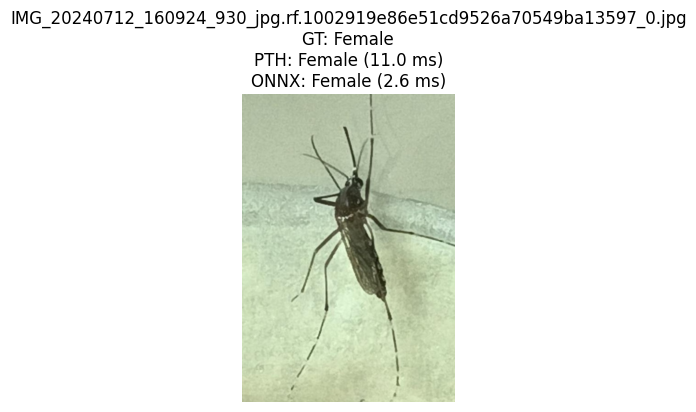

IMG_20240712_160924_930_jpg.rf.1002919e86e51cd9526a70549ba13597_0.jpg
  PTH  -> mean: 10.96 ms | median: 10.83 | std: 0.91 | pred: 0 | gt: 0
  ONNX -> mean: 2.60 ms | median: 2.58 | std: 0.06 | pred: 0 | gt: 0



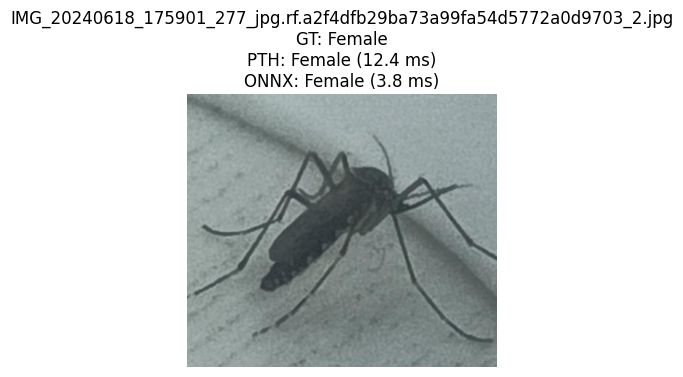

IMG_20240618_175901_277_jpg.rf.a2f4dfb29ba73a99fa54d5772a0d9703_2.jpg
  PTH  -> mean: 12.43 ms | median: 12.18 | std: 1.99 | pred: 0 | gt: 0
  ONNX -> mean: 3.80 ms | median: 3.26 | std: 1.53 | pred: 0 | gt: 0



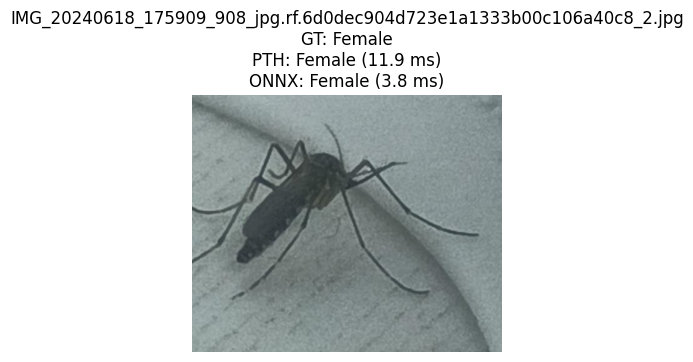

IMG_20240618_175909_908_jpg.rf.6d0dec904d723e1a1333b00c106a40c8_2.jpg
  PTH  -> mean: 11.94 ms | median: 11.92 | std: 1.28 | pred: 0 | gt: 0
  ONNX -> mean: 3.80 ms | median: 3.17 | std: 2.04 | pred: 0 | gt: 0



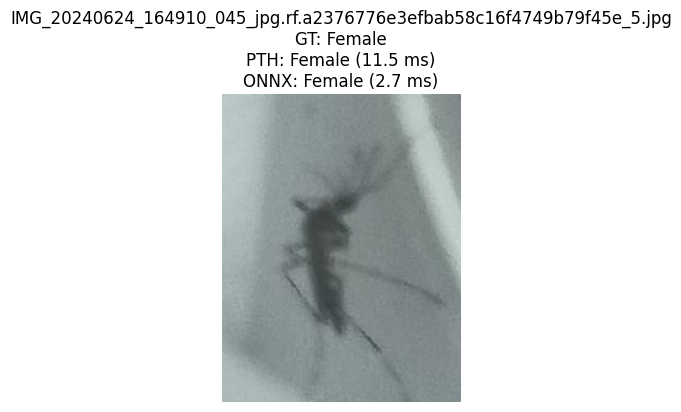

IMG_20240624_164910_045_jpg.rf.a2376776e3efbab58c16f4749b79f45e_5.jpg
  PTH  -> mean: 11.48 ms | median: 10.48 | std: 2.19 | pred: 0 | gt: 0
  ONNX -> mean: 2.70 ms | median: 2.69 | std: 0.14 | pred: 0 | gt: 0



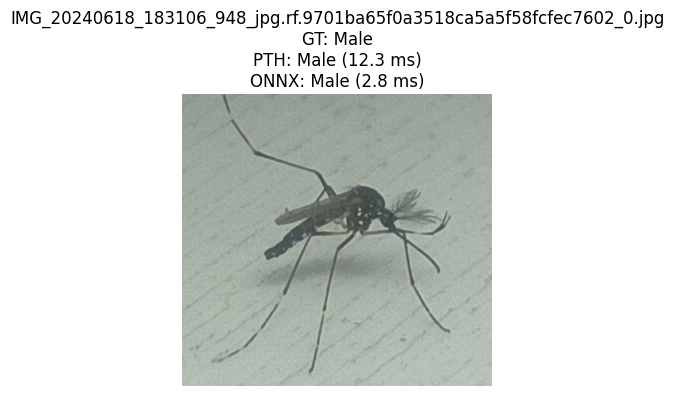

IMG_20240618_183106_948_jpg.rf.9701ba65f0a3518ca5a5f58fcfec7602_0.jpg
  PTH  -> mean: 12.34 ms | median: 11.99 | std: 2.33 | pred: 1 | gt: 1
  ONNX -> mean: 2.85 ms | median: 2.78 | std: 0.27 | pred: 1 | gt: 1



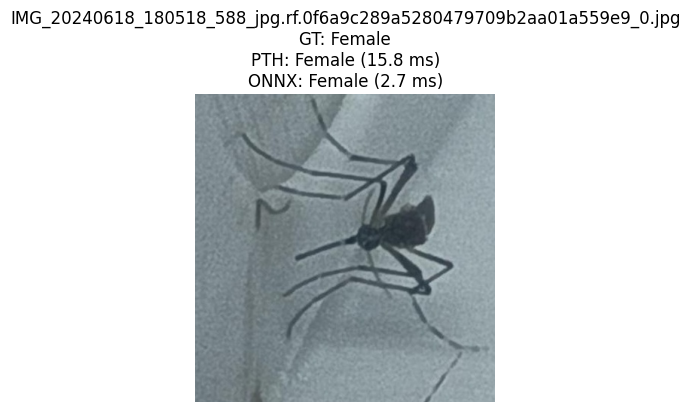

IMG_20240618_180518_588_jpg.rf.0f6a9c289a5280479709b2aa01a559e9_0.jpg
  PTH  -> mean: 15.79 ms | median: 12.56 | std: 10.47 | pred: 0 | gt: 0
  ONNX -> mean: 2.67 ms | median: 2.79 | std: 0.37 | pred: 0 | gt: 0



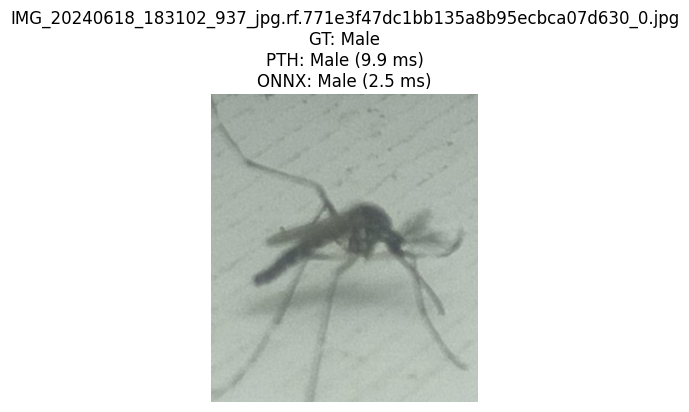

IMG_20240618_183102_937_jpg.rf.771e3f47dc1bb135a8b95ecbca07d630_0.jpg
  PTH  -> mean: 9.92 ms | median: 9.74 | std: 0.41 | pred: 1 | gt: 1
  ONNX -> mean: 2.54 ms | median: 2.54 | std: 0.08 | pred: 1 | gt: 1



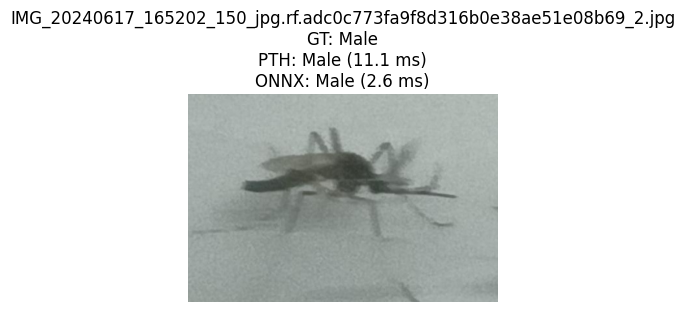

IMG_20240617_165202_150_jpg.rf.adc0c773fa9f8d316b0e38ae51e08b69_2.jpg
  PTH  -> mean: 11.10 ms | median: 11.01 | std: 0.72 | pred: 1 | gt: 1
  ONNX -> mean: 2.65 ms | median: 2.64 | std: 0.13 | pred: 1 | gt: 1



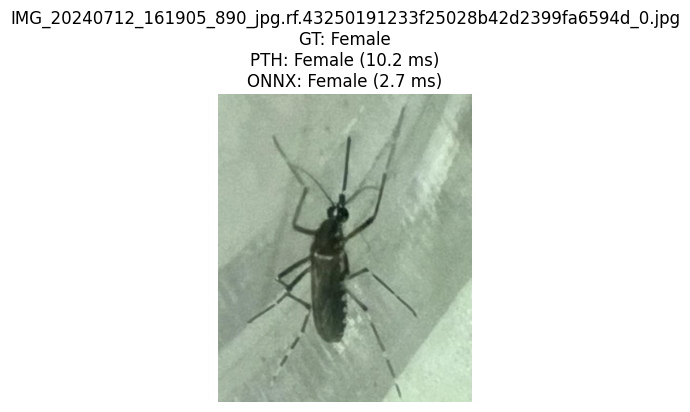

IMG_20240712_161905_890_jpg.rf.43250191233f25028b42d2399fa6594d_0.jpg
  PTH  -> mean: 10.21 ms | median: 10.14 | std: 0.43 | pred: 0 | gt: 0
  ONNX -> mean: 2.68 ms | median: 2.65 | std: 0.14 | pred: 0 | gt: 0



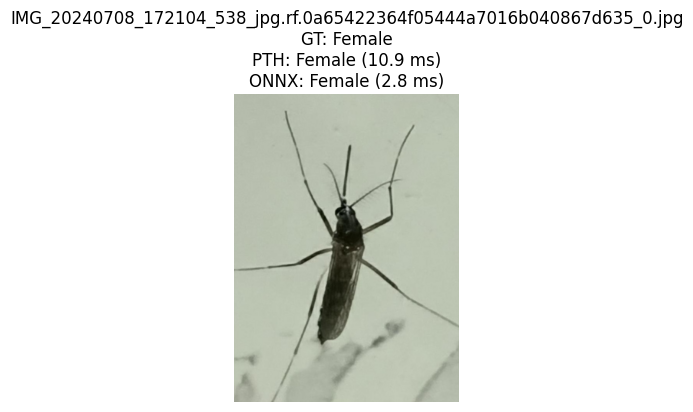

IMG_20240708_172104_538_jpg.rf.0a65422364f05444a7016b040867d635_0.jpg
  PTH  -> mean: 10.89 ms | median: 10.84 | std: 0.45 | pred: 0 | gt: 0
  ONNX -> mean: 2.85 ms | median: 2.82 | std: 0.16 | pred: 0 | gt: 0


===== METRICS (10 samples) =====

PTH:
Accuracy: 1.0
              precision    recall  f1-score   support

      Female       1.00      1.00      1.00         7
        Male       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

[[7 0]
 [0 3]]

ONNX:
Accuracy: 1.0
              precision    recall  f1-score   support

      Female       1.00      1.00      1.00         7
        Male       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

[[7 0]
 [0 3]]

===== FINAL LATENCY =====
PTH

In [25]:
import os
import cv2
import torch
import numpy as np
import onnxruntime as ort
from pathlib import Path
import time
import statistics
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import random

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATASET PATCH (SUBSET: TEST)
DATASET_TEST_PATH = ROOT/ "0_Datasets" / "Male_and_female_cls" / "test"

# MODELS
MOBILENET_MODEL_PTH_PATH = ROOT / "Models" / "best_CLmodel.pth"
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

# =========================
# CONFIG
# =========================
IMG_SIZE = 160
CLASS_NAMES = ["Female", "Male"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_ONNX_GPU = False

N_RUNS = 10
WARMUP = 3
N_SAMPLES = 10   # LIMIT HERE

# =========================
# NORMALIZATION
# =========================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

# =========================
# PREPROCESS
# =========================
def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = (img - MEAN) / STD

    return np.expand_dims(img, axis=0).astype(np.float32)

# =========================
# LOAD DATASET
# =========================
def load_dataset():
    images, labels, paths = [], [], []

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        folder = Path(DATASET_TEST_PATH) / cls_name

        for img_path in folder.glob("*.*"):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            images.append(img)
            labels.append(cls_id)
            paths.append(img_path.name)

    return images, np.array(labels), paths

# =========================
# LOAD MODELS
# =========================
def load_pth():
    from torchvision import models

    model = models.mobilenet_v3_large(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = torch.nn.Linear(in_features, len(CLASS_NAMES))

    state_dict = torch.load(MOBILENET_MODEL_PTH_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict)

    model.to(DEVICE)
    model.eval()

    return model

def load_onnx():
    providers = ["CPUExecutionProvider"]
    if USE_ONNX_GPU:
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

    session = ort.InferenceSession(MOBILENET_MODEL_ONNX_PATH, providers=providers)
    input_name = session.get_inputs()[0].name

    return session, input_name

# =========================
# TIMING
# =========================
def measure_pth(model, img):
    inp = torch.tensor(preprocess(img)).to(DEVICE)
    times = []

    for i in range(WARMUP + N_RUNS):
        if DEVICE == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model(inp)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)

    return times

def measure_onnx(session, input_name, img):
    inp = preprocess(img)
    times = []

    for i in range(WARMUP + N_RUNS):
        t0 = time.perf_counter()
        _ = session.run(None, {input_name: inp})
        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)

    return times

# =========================
# PREDICTION
# =========================
def predict_pth(model, img):
    inp = torch.tensor(preprocess(img)).to(DEVICE)
    with torch.no_grad():
        out = model(inp)
    return torch.argmax(out, dim=1).item()

def predict_onnx(session, input_name, img):
    inp = preprocess(img)
    out = session.run(None, {input_name: inp})[0]
    return int(np.argmax(out, axis=1)[0])

# =========================
# MAIN
# =========================
def evaluate():
    images, labels, paths = load_dataset()
    print(f"Total dataset size: {len(images)}")

    # RANDOM SAMPLE OF 10
    indices = random.sample(range(len(images)), min(N_SAMPLES, len(images)))

    images = [images[i] for i in indices]
    labels = labels[indices]
    paths = [paths[i] for i in indices]

    print(f"Using {len(images)} samples for evaluation\n")

    pth_model = load_pth()
    onnx_sess, input_name = load_onnx()

    all_pth_times = []
    all_onnx_times = []

    preds_pth = []
    preds_onnx = []

    for img, gt, name in zip(images, labels, paths):

        # -------- TIMING --------
        pth_times = measure_pth(pth_model, img)
        onnx_times = measure_onnx(onnx_sess, input_name, img)

        all_pth_times.extend(pth_times)
        all_onnx_times.extend(onnx_times)

        # Stats
        pth_mean = statistics.mean(pth_times)
        pth_median = statistics.median(pth_times)
        pth_std = statistics.stdev(pth_times)

        onnx_mean = statistics.mean(onnx_times)
        onnx_median = statistics.median(onnx_times)
        onnx_std = statistics.stdev(onnx_times)

        # -------- PRED --------
        pred_pth = predict_pth(pth_model, img)
        pred_onnx = predict_onnx(onnx_sess, input_name, img)

        preds_pth.append(pred_pth)
        preds_onnx.append(pred_onnx)

        # -------- VISUAL --------
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        title = (
            f"{name}\n"
            f"GT: {CLASS_NAMES[gt]}\n"
            f"PTH: {CLASS_NAMES[pred_pth]} ({pth_mean:.1f} ms)\n"
            f"ONNX: {CLASS_NAMES[pred_onnx]} ({onnx_mean:.1f} ms)"
        )

        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb)
        plt.title(title)
        plt.axis("off")
        plt.show()

        # -------- TERMINAL --------
        print(f"{name}")
        print(f"  PTH  -> mean: {pth_mean:.2f} ms | median: {pth_median:.2f} | std: {pth_std:.2f} | pred: {pred_pth} | gt: {gt}")
        print(f"  ONNX -> mean: {onnx_mean:.2f} ms | median: {onnx_median:.2f} | std: {onnx_std:.2f} | pred: {pred_onnx} | gt: {gt}")
        print("")

    preds_pth = np.array(preds_pth)
    preds_onnx = np.array(preds_onnx)

    # =========================
    # METRICS (ONLY 10 SAMPLES)
    # =========================
    print("\n===== METRICS (10 samples) =====")

    print("\nPTH:")
    print("Accuracy:", accuracy_score(labels, preds_pth))
    print(classification_report(labels, preds_pth, target_names=CLASS_NAMES))
    print(confusion_matrix(labels, preds_pth))

    print("\nONNX:")
    print("Accuracy:", accuracy_score(labels, preds_onnx))
    print(classification_report(labels, preds_onnx, target_names=CLASS_NAMES))
    print(confusion_matrix(labels, preds_onnx))

    # =========================
    # FINAL LATENCY
    # =========================
    print("\n===== FINAL LATENCY =====")

    print(f"PTH  -> mean: {statistics.mean(all_pth_times):.2f} ms | "
          f"median: {statistics.median(all_pth_times):.2f} | "
          f"std: {statistics.stdev(all_pth_times):.2f}")

    print(f"ONNX -> mean: {statistics.mean(all_onnx_times):.2f} ms | "
          f"median: {statistics.median(all_onnx_times):.2f} | "
          f"std: {statistics.stdev(all_onnx_times):.2f}")

    # =========================
    # DISAGREEMENTS
    # =========================
    print("\n===== DISAGREEMENTS =====")
    mismatches = np.where(preds_pth != preds_onnx)[0]

    for i in mismatches:
        print(f"[{i}] GT={labels[i]} | PTH={preds_pth[i]} | ONNX={preds_onnx[i]}")

    print(f"\nTotal mismatches: {len(mismatches)}")


if __name__ == "__main__":
    evaluate()

In [1]:
import os
import cv2
import time
import torch
import statistics
import numpy as np
import onnxruntime as ort

from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATASET PATCH (SUBSET: TEST)
DATASET_TEST_PATH = ROOT/ "0_Datasets" / "Male_and_female_cls" / "test"

# MODELS
MOBILENET_MODEL_PTH_PATH = ROOT / "Models" / "best_CLmodel.pth"
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

# =========================================================
# CONFIG
# =========================================================
IMG_SIZE = 160
CLASS_NAMES = ["Female", "Male"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ONNX GPU
USE_ONNX_GPU = False

# Timing
N_RUNS = 10
WARMUP = 3

# =========================================================
# NORMALIZATION
# =========================================================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

# =========================================================
# PREPROCESS
# =========================================================
def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = (img - MEAN) / STD

    return np.expand_dims(img, axis=0).astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================
def load_dataset():
    images = []
    labels = []
    paths = []

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        folder = Path(DATASET_TEST_PATH) / cls_name

        for img_path in folder.glob("*.*"):
            img = cv2.imread(str(img_path))

            if img is None:
                continue

            images.append(img)
            labels.append(cls_id)
            paths.append(str(img_path))

    return images, np.array(labels), paths

# =========================================================
# LOAD PTH MODEL
# =========================================================
def load_pth():
    from torchvision import models

    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[3].in_features
    model.classifier[3] = torch.nn.Linear(
        in_features,
        len(CLASS_NAMES)
    )

    state_dict = torch.load(MOBILENET_MODEL_PTH_PATH, map_location=DEVICE)

    model.load_state_dict(state_dict)

    model.to(DEVICE)
    model.eval()

    return model

# =========================================================
# LOAD ONNX MODEL
# =========================================================
def load_onnx():

    providers = ["CPUExecutionProvider"]

    if USE_ONNX_GPU:
        providers = [
            "CUDAExecutionProvider",
            "CPUExecutionProvider"
        ]

    session = ort.InferenceSession(
        MOBILENET_MODEL_ONNX_PATH,
        providers=providers
    )

    input_name = session.get_inputs()[0].name

    return session, input_name

# =========================================================
# TIMING
# =========================================================
def measure_pth(model, img):

    inp = torch.tensor(preprocess(img)).to(DEVICE)

    times = []

    for i in range(WARMUP + N_RUNS):

        if DEVICE == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()

        with torch.no_grad():
            _ = model(inp)

        if DEVICE == "cuda":
            torch.cuda.synchronize()

        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)

    return times

def measure_onnx(session, input_name, img):

    inp = preprocess(img)

    times = []

    for i in range(WARMUP + N_RUNS):

        t0 = time.perf_counter()

        _ = session.run(None, {input_name: inp})

        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)

    return times

# =========================================================
# PREDICTION
# =========================================================
def predict_pth(model, img):

    inp = torch.tensor(preprocess(img)).to(DEVICE)

    with torch.no_grad():
        out = model(inp)

    pred = torch.argmax(out, dim=1).item()

    return pred

def predict_onnx(session, input_name, img):

    inp = preprocess(img)

    out = session.run(None, {input_name: inp})[0]

    pred = int(np.argmax(out, axis=1)[0])

    return pred

# =========================================================
# METRICS PRINT
# =========================================================
def print_metrics(name, gt, preds):

    print(f"\n================ {name} =================")

    acc = accuracy_score(gt, preds)
    precision = precision_score(gt, preds, average="weighted")
    recall = recall_score(gt, preds, average="weighted")
    f1 = f1_score(gt, preds, average="weighted")

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            gt,
            preds,
            target_names=CLASS_NAMES,
            digits=4
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(gt, preds))

# =========================================================
# LATENCY PRINT
# =========================================================
def print_latency(name, times):

    print(f"\n================ {name} LATENCY =================")

    print(f"Mean   : {statistics.mean(times):.4f} ms")
    print(f"Median : {statistics.median(times):.4f} ms")
    print(f"Std    : {statistics.stdev(times):.4f} ms")
    print(f"Min    : {min(times):.4f} ms")
    print(f"Max    : {max(times):.4f} ms")

    fps = 1000.0 / statistics.mean(times)

    print(f"FPS    : {fps:.2f}")

# =========================================================
# MAIN EVALUATION
# =========================================================
def evaluate():

    print("\nLoading dataset...")
    images, labels, paths = load_dataset()

    print(f"Total images: {len(images)}")

    print("\nLoading models...")

    pth_model = load_pth()
    onnx_session, input_name = load_onnx()

    # -----------------------------------------------------
    # STORAGE
    # -----------------------------------------------------
    preds_pth = []
    preds_onnx = []

    all_pth_times = []
    all_onnx_times = []

    # -----------------------------------------------------
    # LOOP
    # -----------------------------------------------------
    total = len(images)

    for idx, (img, gt, path) in enumerate(zip(images, labels, paths)):

        filename = os.path.basename(path)

        print(f"[{idx+1}/{total}] {filename}")

        # =========================
        # TIMING
        # =========================
        pth_times = measure_pth(pth_model, img)
        onnx_times = measure_onnx(onnx_session, input_name, img)

        all_pth_times.extend(pth_times)
        all_onnx_times.extend(onnx_times)

        # =========================
        # PREDICTIONS
        # =========================
        pred_pth = predict_pth(pth_model, img)
        pred_onnx = predict_onnx(onnx_session, input_name, img)

        preds_pth.append(pred_pth)
        preds_onnx.append(pred_onnx)

    # -----------------------------------------------------
    # CONVERT
    # -----------------------------------------------------
    preds_pth = np.array(preds_pth)
    preds_onnx = np.array(preds_onnx)

    # =====================================================
    # METRICS
    # =====================================================
    print_metrics("PTH", labels, preds_pth)
    print_metrics("ONNX", labels, preds_onnx)

    # =====================================================
    # LATENCY
    # =====================================================
    print_latency("PTH", all_pth_times)
    print_latency("ONNX", all_onnx_times)

    # =====================================================
    # AGREEMENT
    # =====================================================
    mismatches = np.where(preds_pth != preds_onnx)[0]

    print("\n================ MODEL DISAGREEMENTS =================")

    print(f"Total mismatches: {len(mismatches)}")

    if len(mismatches) > 0:

        for i in mismatches:

            print(
                f"{os.path.basename(paths[i])} | "
                f"GT={CLASS_NAMES[labels[i]]} | "
                f"PTH={CLASS_NAMES[preds_pth[i]]} | "
                f"ONNX={CLASS_NAMES[preds_onnx[i]]}"
            )

# =========================================================
# ENTRY
# =========================================================
if __name__ == "__main__":
    evaluate()


Loading dataset...
Total images: 446

Loading models...
[1/446] DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295_0.jpg
[2/446] DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295_1.jpg
[3/446] DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295_2.jpg
[4/446] DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295_3.jpg
[5/446] DSCN5049_JPG.rf.f630321cc895d78d83b24161b49c9109_0.jpg
[6/446] DSCN5058_JPG.rf.055130f0af78595ce3561a1c9a22cbd9_0.jpg
[7/446] DSCN5062_JPG.rf.d3867527a6e249c2bc3c02bc783086f9_0.jpg
[8/446] DSCN5062_JPG.rf.d3867527a6e249c2bc3c02bc783086f9_1.jpg
[9/446] DSCN5066_JPG.rf.bb148da32486b7d0c7ba20eb290f83cd_0.jpg
[10/446] DSCN5068_JPG.rf.df217ba5571890c4480a5dcf5a487a19_0.jpg
[11/446] DSCN5068_JPG.rf.df217ba5571890c4480a5dcf5a487a19_1.jpg
[12/446] DSCN5073_JPG.rf.83a0017eae8948055b55df74501fa16d_0.jpg
[13/446] DSCN5073_JPG.rf.83a0017eae8948055b55df74501fa16d_1.jpg
[14/446] DSCN5073_JPG.rf.83a0017eae8948055b55df74501fa16d_2.jpg
[15/446] DSCN5074_JPG.rf.7bac6cad2bfcc5c35bc5280044f561f

In [ ]:
"""
benchmark_inference.py
======================
Mide el tiempo de inferencia medio sobre TODO el dataset de test para:
  - ONNX  (CPU)
  - PyTorch (CPU)
  - PyTorch (GPU / CUDA) — se omite si no hay GPU disponible
 
Salida: tabla con mean / median / std / P95 / P99 (en ms) por backend,
        y un gráfico de barras guardado en benchmark_results.png
"""
 
import os
import time
import statistics
import random
from pathlib import Path
 
import cv2
import numpy as np
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
# =============================================================================
# CONFIG  — ajusta estas rutas y parámetros
# =============================================================================
DATASET_TEST_PATH = "dataset_cls/test"
MOBILENET_MODEL_PTH_PATH     = "best_model_fixed.pth"
MOBILENET_MODEL_ONNX_PATH    = "best_CLmodel_fixed.onnx"
 
IMG_SIZE     = 160
CLASS_NAMES  = ["Female", "Male"]
 
N_RUNS  = 10    # repeticiones por imagen (para latencia estable)
WARMUP  = 3     # repeticiones de calentamiento (descartadas)
 
# Pon None para usar todo el dataset; pon un entero para muestrear N imágenes
N_SAMPLES = None  # e.g. 200 para un benchmark rápido
 
# =============================================================================
# NORMALIZACIÓN ImageNet
# =============================================================================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)
 
 
# =============================================================================
# PREPROCESADO
# =============================================================================
def preprocess_np(img: np.ndarray) -> np.ndarray:
    """BGR → RGB → resize → normalize → (1, C, H, W) float32."""
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = (img - MEAN) / STD
    return np.expand_dims(img, axis=0).astype(np.float32)
 
 
# =============================================================================
# CARGA DEL DATASET
# =============================================================================
def load_dataset():
    images, labels, paths = [], [], []
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        folder = Path(DATASET_TEST_PATH) / cls_name
        for img_path in sorted(folder.glob("*.*")):
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            images.append(img)
            labels.append(cls_id)
            paths.append(img_path.name)
    return images, np.array(labels), paths
 
 
# =============================================================================
# CARGA DE MODELOS
# =============================================================================
def load_pth(device: str):
    from torchvision import models
    model = models.mobilenet_v3_large(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = torch.nn.Linear(in_features, len(CLASS_NAMES))
    state_dict = torch.load(MOBILENET_MODEL_PTH_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model
 
 
def load_onnx_cpu():
    session = ort.InferenceSession(
        MOBILENET_MODEL_ONNX_PATH,
        providers=["CPUExecutionProvider"]
    )
    input_name = session.get_inputs()[0].name
    return session, input_name
 
 
# =============================================================================
# RUTINAS DE MEDICIÓN POR IMAGEN
# =============================================================================
def time_pth(model, device: str, img_np: np.ndarray) -> list[float]:
    """Devuelve lista de N_RUNS tiempos en ms (sin warmup)."""
    inp = torch.from_numpy(preprocess_np(img_np)).to(device)
    times = []
    for i in range(WARMUP + N_RUNS):
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model(inp)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        if i >= WARMUP:
            times.append((t1 - t0) * 1e3)
    return times
 
 
def time_onnx(session, input_name: str, img_np: np.ndarray) -> list[float]:
    """Devuelve lista de N_RUNS tiempos en ms (sin warmup)."""
    inp = preprocess_np(img_np)
    times = []
    for i in range(WARMUP + N_RUNS):
        t0 = time.perf_counter()
        _ = session.run(None, {input_name: inp})
        t1 = time.perf_counter()
        if i >= WARMUP:
            times.append((t1 - t0) * 1e3)
    return times
 
 
# =============================================================================
# ESTADÍSTICAS AGREGADAS
# =============================================================================
def aggregate(all_times: list[float]) -> dict:
    s = sorted(all_times)
    n = len(s)
    return {
        "mean":   statistics.mean(s),
        "median": statistics.median(s),
        "std":    statistics.stdev(s) if n > 1 else 0.0,
        "p95":    s[int(0.95 * n) - 1],
        "p99":    s[int(0.99 * n) - 1],
        "n_runs": n,
    }
 
 
def print_stats(label: str, stats: dict):
    print(f"  {label:<22} "
          f"mean={stats['mean']:7.2f} ms  "
          f"median={stats['median']:7.2f} ms  "
          f"std={stats['std']:6.2f} ms  "
          f"P95={stats['p95']:7.2f} ms  "
          f"P99={stats['p99']:7.2f} ms  "
          f"(n={stats['n_runs']})")
 
 
# =============================================================================
# GRÁFICO
# =============================================================================
def plot_results(results: dict, save_path: str = "benchmark_results.png"):
    labels = list(results.keys())
    means  = [results[k]["mean"]   for k in labels]
    stds   = [results[k]["std"]    for k in labels]
    p95s   = [results[k]["p95"]    for k in labels]
 
    x = np.arange(len(labels))
    width = 0.28
 
    fig, ax = plt.subplots(figsize=(9, 5))
    bars_mean = ax.bar(x - width, means, width, label="Mean",   color="#4C72B0", yerr=stds, capsize=5)
    bars_med  = ax.bar(x,         [results[k]["median"] for k in labels], width, label="Median", color="#55A868")
    bars_p95  = ax.bar(x + width, p95s,  width, label="P95",    color="#C44E52")
 
    ax.set_xlabel("Backend")
    ax.set_ylabel("Latencia (ms)")
    ax.set_title("Benchmark de inferencia — dataset de test completo\n(MobileNetV3-Large, imagen única, CPU/GPU)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.5)
 
    for bar in [*bars_mean, *bars_med, *bars_p95]:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)
 
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"\nGráfico guardado en: {save_path}")
    plt.show()
 
 
# =============================================================================
# MAIN
# =============================================================================
def benchmark():
    # ── Carga dataset ───────────────────────────────────────────────────────
    print("Cargando dataset...")
    images, labels, paths = load_dataset()
    total = len(images)
    print(f"  Total imágenes encontradas: {total}")
 
    if N_SAMPLES is not None and N_SAMPLES < total:
        idx = random.sample(range(total), N_SAMPLES)
        images = [images[i] for i in idx]
        labels = labels[idx]
        paths  = [paths[i]  for i in idx]
        print(f"  Muestreando {len(images)} imágenes (N_SAMPLES={N_SAMPLES})\n")
    else:
        print(f"  Usando TODO el dataset ({total} imágenes)\n")
 
    # ── Detectar GPU ─────────────────────────────────────────────────────────
    has_cuda = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if has_cuda else "—"
    print(f"CUDA disponible: {has_cuda}" + (f"  ({gpu_name})" if has_cuda else ""))
    print(f"Configuración: WARMUP={WARMUP}, N_RUNS={N_RUNS} por imagen\n")
 
    # ── Cargar modelos ───────────────────────────────────────────────────────
    print("Cargando modelos...")
    onnx_sess, input_name = load_onnx_cpu()
    pth_cpu_model         = load_pth("cpu")
    pth_gpu_model         = load_pth("cuda") if has_cuda else None
    print("  Modelos listos.\n")
 
    # ── Bucle principal ──────────────────────────────────────────────────────
    all_times: dict[str, list[float]] = {
        "ONNX (CPU)":    [],
        "PyTorch (CPU)": [],
    }
    if has_cuda:
        all_times["PyTorch (GPU)"] = []
 
    n = len(images)
    for idx, (img, gt, name) in enumerate(zip(images, labels, paths), 1):
        if idx % max(1, n // 20) == 0 or idx == n:
            print(f"  [{idx:>{len(str(n))}}/{n}]  {name}")
 
        all_times["ONNX (CPU)"].extend(time_onnx(onnx_sess, input_name, img))
        all_times["PyTorch (CPU)"].extend(time_pth(pth_cpu_model, "cpu", img))
        if has_cuda:
            all_times["PyTorch (GPU)"].extend(time_pth(pth_gpu_model, "cuda", img))
 
    # ── Resultados ───────────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("RESULTADOS FINALES — latencia de inferencia (imagen única, batch=1)")
    print("=" * 70)
 
    results = {}
    for backend, times in all_times.items():
        stats = aggregate(times)
        results[backend] = stats
        print_stats(backend, stats)
 
    # ── Speedup relativo ─────────────────────────────────────────────────────
    ref_mean = results["ONNX (CPU)"]["mean"]
    print("\nSpeedup respecto a ONNX (CPU):")
    for backend, stats in results.items():
        ratio = ref_mean / stats["mean"]
        direction = "más rápido" if ratio >= 1 else "más lento"
        print(f"  {backend:<22} → {ratio:.2f}x {direction}")
 
    # ── Gráfico ──────────────────────────────────────────────────────────────
    plot_results(results)
 
 
if __name__ == "__main__":
    benchmark()

Loading dataset...
  Total images found: 446
  Using the FULL dataset (446 images)

CUDA available: True  (NVIDIA GeForce RTX 5060 Laptop GPU)

Loading models...
  Models ready.

Running inference...
  [ 22/446]  DSCN5095_JPG.rf.4bba664c284c156217cb745f3369c776_1.jpg
  [ 44/446]  IMG_1096_JPG.rf.42741985b8e096310744b073c72603be_1.jpg
  [ 66/446]  IMG_1122_JPG.rf.fb6549dcf19dd306bbf43bc34942bd7c_0.jpg
  [ 88/446]  IMG_20240617_172926_200_jpg.rf.e3b6a3bd965b5b19dd95b55104f2c24e_0.jpg
  [110/446]  IMG_20240618_175938_697_jpg.rf.cb26f3d21d1dc946c48dd306ccaa653f_0.jpg
  [132/446]  IMG_20240620_152930_156_jpg.rf.6589da6d948e05cbdb38efb7bafded2b_0.jpg
  [154/446]  IMG_20240624_164000_120_jpg.rf.fe4c5d1662577f70a84623e261475d67_1.jpg
  [176/446]  IMG_20240704_133905_571_jpg.rf.8250c9621972c18eed912f0a1811dbf4_0.jpg
  [198/446]  IMG_20240708_172044_623_jpg.rf.3b373978d42eaf8f7a65613d82544d9e_0.jpg
  [220/446]  IMG_20240723_182724_670_jpg.rf.cbf33803024119dff455e7a55d4ae7a6_0.jpg
  [242/446]  DS

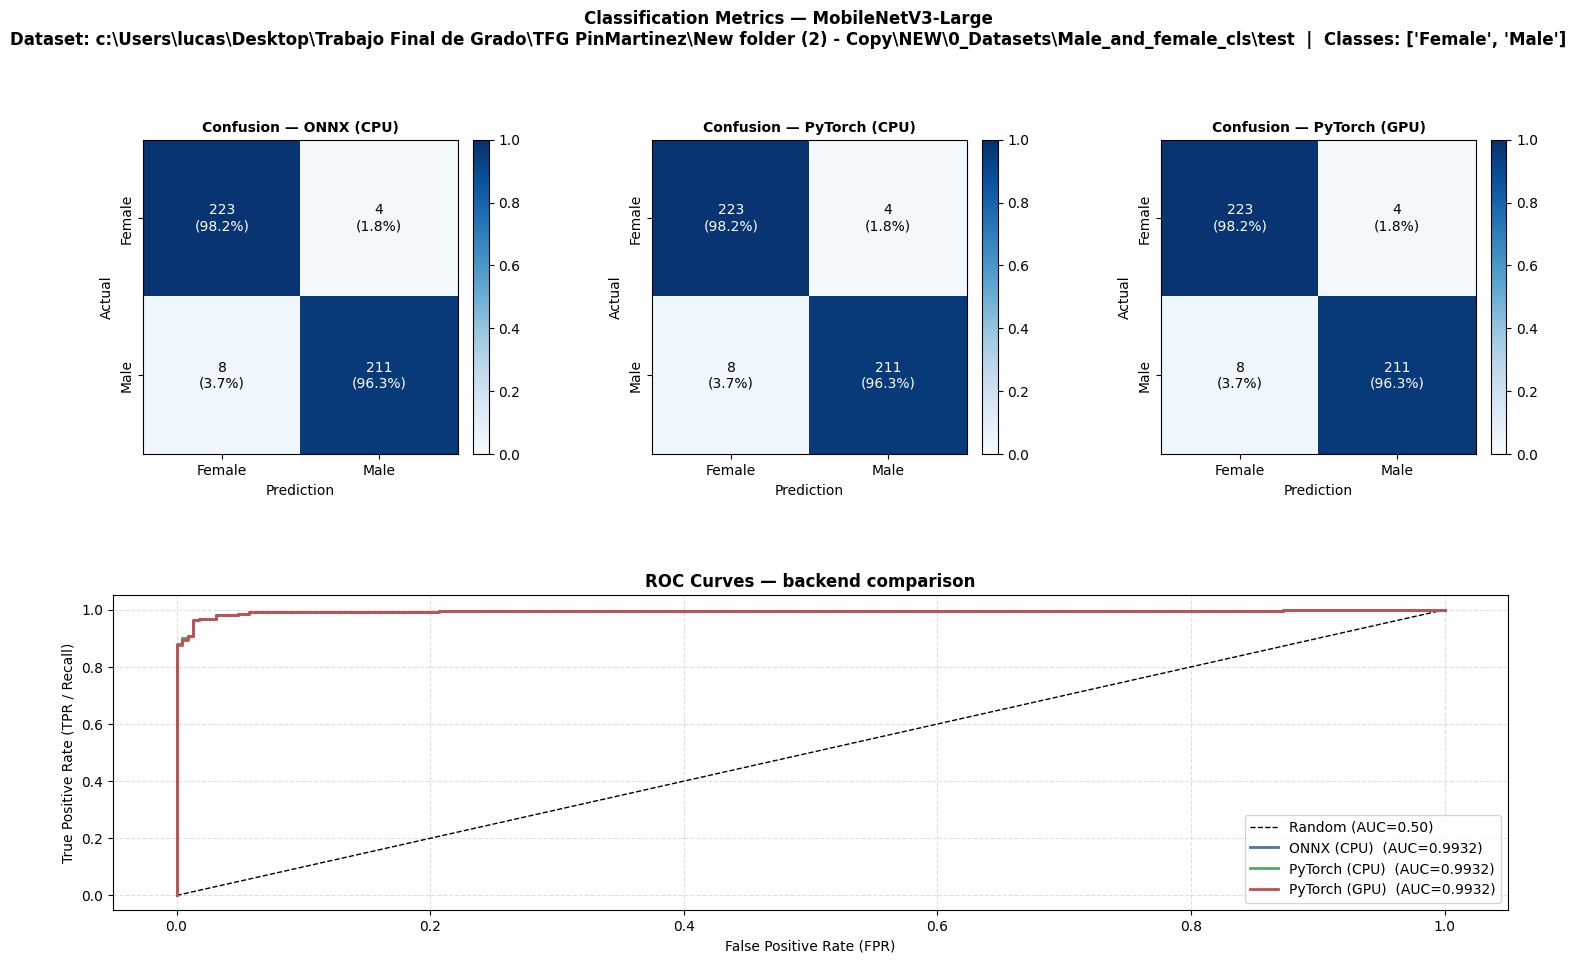

In [3]:
"""
evaluate_metrics.py
===================
Computes classification metrics over the ENTIRE test dataset for:
  - ONNX  (CPU)
  - PyTorch (CPU)
  - PyTorch (GPU / CUDA) — skipped if no GPU is available

Output: table with Accuracy / Precision / Recall / F1 / AUC-ROC per backend,
        confusion matrix and ROC curve saved to metrics_results.png
"""

import os
import random
from pathlib import Path

import cv2
import numpy as np
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATASET PATH (SUBSET: TEST)
DATASET_TEST_PATH = ROOT / "0_Datasets" / "Male_and_female_cls" / "test"

# MODELS
MOBILENET_MODEL_PTH_PATH  = ROOT / "Models" / "best_CLmodel.pth"
MOBILENET_MODEL_ONNX_PATH = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

# =============================================================================
# CONFIG
# =============================================================================
IMG_SIZE    = 160
CLASS_NAMES = ["Female", "Male"]

# Set to None to use the full dataset; set an integer to sample N images
N_SAMPLES = None  # e.g. 200 for a quick evaluation

# =============================================================================
# ImageNet NORMALIZATION
# =============================================================================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


# =============================================================================
# PREPROCESSING
# =============================================================================
def preprocess_np(img: np.ndarray) -> np.ndarray:
    """BGR → RGB → resize → normalize → (1, C, H, W) float32."""
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = (img - MEAN) / STD
    return np.expand_dims(img, axis=0).astype(np.float32)


# =============================================================================
# DATASET LOADING
# =============================================================================
def load_dataset():
    images, labels, paths = [], [], []
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        folder = Path(DATASET_TEST_PATH) / cls_name
        for img_path in sorted(folder.glob("*.*")):
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            images.append(img)
            labels.append(cls_id)
            paths.append(img_path.name)
    return images, np.array(labels), paths


# =============================================================================
# MODEL LOADING
# =============================================================================
def load_pth(device: str):
    from torchvision import models
    model = models.mobilenet_v3_large(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = torch.nn.Linear(in_features, len(CLASS_NAMES))
    state_dict = torch.load(MOBILENET_MODEL_PTH_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def load_onnx_cpu():
    session = ort.InferenceSession(
        MOBILENET_MODEL_ONNX_PATH,
        providers=["CPUExecutionProvider"]
    )
    input_name = session.get_inputs()[0].name
    return session, input_name


# =============================================================================
# PER-IMAGE INFERENCE — returns (pred_class, positive_class_probability)
# =============================================================================
def predict_pth(model, device: str, img_np: np.ndarray) -> tuple[int, float]:
    inp = torch.from_numpy(preprocess_np(img_np)).to(device)
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = int(np.argmax(probs))
    return pred, float(probs[1])   # prob of class 1 (Male / positive)


def predict_onnx(session, input_name: str, img_np: np.ndarray) -> tuple[int, float]:
    inp    = preprocess_np(img_np)
    logits = session.run(None, {input_name: inp})[0][0]
    probs  = np.exp(logits) / np.sum(np.exp(logits))  # manual softmax
    pred   = int(np.argmax(probs))
    return pred, float(probs[1])


# =============================================================================
# METRICS COMPUTATION
# =============================================================================
def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    y_prob: np.ndarray) -> dict:
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "auc_roc":   roc_auc_score(y_true, y_prob),
        "conf_mat":  confusion_matrix(y_true, y_pred),
        "fpr":       roc_curve(y_true, y_prob)[0],
        "tpr":       roc_curve(y_true, y_prob)[1],
    }


def print_metrics(label: str, m: dict):
    print(f"\n  {'─' * 50}")
    print(f"  Backend: {label}")
    print(f"  {'─' * 50}")
    print(f"  Accuracy : {m['accuracy']:.4f}  ({m['accuracy']*100:.2f}%)")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  Recall   : {m['recall']:.4f}")
    print(f"  F1-Score : {m['f1']:.4f}")
    print(f"  AUC-ROC  : {m['auc_roc']:.4f}")
    print(f"\n  Confusion matrix (rows=actual, cols=predicted):")
    cm = m["conf_mat"]
    for i, row in enumerate(cm):
        print(f"    {CLASS_NAMES[i]:<8} → {row}")


# =============================================================================
# PLOT: confusion matrices + ROC curves
# =============================================================================
def plot_results(results: dict, save_path: str = "metrics_results.png"):
    backends = list(results.keys())
    n = len(backends)

    fig = plt.figure(figsize=(6 * n, 10))
    gs  = gridspec.GridSpec(2, n, figure=fig, hspace=0.45, wspace=0.35)

    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    # ── Row 0: confusion matrices ─────────────────────────────────────────────
    for col, (backend, m) in enumerate(results.items()):
        ax  = fig.add_subplot(gs[0, col])
        cm  = m["conf_mat"].astype(float)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES, rotation=90, va="center")
        ax.set_xlabel("Prediction"); ax.set_ylabel("Actual")
        ax.set_title(f"Confusion — {backend}", fontsize=10, fontweight="bold")

        for i in range(2):
            for j in range(2):
                val_abs = int(cm[i, j])
                val_pct = cm_norm[i, j] * 100
                color   = "white" if cm_norm[i, j] > 0.6 else "black"
                ax.text(j, i, f"{val_abs}\n({val_pct:.1f}%)",
                        ha="center", va="center", fontsize=10, color=color)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── Row 1: overlaid ROC curves ────────────────────────────────────────────
    ax_roc = fig.add_subplot(gs[1, :])
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.50)")

    for (backend, m), color in zip(results.items(), colors):
        label = f"{backend}  (AUC={m['auc_roc']:.4f})"
        ax_roc.plot(m["fpr"], m["tpr"], lw=2, color=color, label=label)

    ax_roc.set_xlabel("False Positive Rate (FPR)")
    ax_roc.set_ylabel("True Positive Rate (TPR / Recall)")
    ax_roc.set_title("ROC Curves — backend comparison", fontweight="bold")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(linestyle="--", alpha=0.4)

    fig.suptitle(
        "Classification Metrics — MobileNetV3-Large\n"
        f"Dataset: {DATASET_TEST_PATH}  |  Classes: {CLASS_NAMES}",
        fontsize=12, fontweight="bold", y=1.01
    )

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved to: {save_path}")
    plt.show()


# =============================================================================
# COMPARATIVE SUMMARY TABLE
# =============================================================================
def print_summary_table(results: dict):
    cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
    keys = ["accuracy", "precision", "recall", "f1", "auc_roc"]
    header = f"  {'Backend':<22}" + "".join(f"{c:>12}" for c in cols)
    print("\n" + "=" * len(header))
    print("COMPARATIVE SUMMARY")
    print("=" * len(header))
    print(header)
    print("  " + "─" * (len(header) - 2))
    for backend, m in results.items():
        row = f"  {backend:<22}" + "".join(f"{m[k]:>12.4f}" for k in keys)
        print(row)
    print("=" * len(header))


# =============================================================================
# MAIN
# =============================================================================
def evaluate():
    # ── Load dataset ──────────────────────────────────────────────────────────
    print("Loading dataset...")
    images, labels, paths = load_dataset()
    total = len(images)
    print(f"  Total images found: {total}")

    if N_SAMPLES is not None and N_SAMPLES < total:
        idx    = random.sample(range(total), N_SAMPLES)
        images = [images[i] for i in idx]
        labels = labels[idx]
        paths  = [paths[i]  for i in idx]
        print(f"  Sampling {len(images)} images (N_SAMPLES={N_SAMPLES})\n")
    else:
        print(f"  Using the FULL dataset ({total} images)\n")

    # ── Detect GPU ────────────────────────────────────────────────────────────
    has_cuda = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if has_cuda else "—"
    print(f"CUDA available: {has_cuda}" + (f"  ({gpu_name})" if has_cuda else ""))

    # ── Load models ───────────────────────────────────────────────────────────
    print("\nLoading models...")
    onnx_sess, input_name = load_onnx_cpu()
    pth_cpu_model         = load_pth("cpu")
    pth_gpu_model         = load_pth("cuda") if has_cuda else None
    print("  Models ready.\n")

    # ── Accumulators ──────────────────────────────────────────────────────────
    preds: dict[str, list[int]]   = {
        "ONNX (CPU)":    [],
        "PyTorch (CPU)": [],
    }
    probs: dict[str, list[float]] = {k: [] for k in preds}
    if has_cuda:
        preds["PyTorch (GPU)"] = []
        probs["PyTorch (GPU)"] = []

    # ── Inference loop ────────────────────────────────────────────────────────
    n = len(images)
    print("Running inference...")
    for idx, (img, gt, name) in enumerate(zip(images, labels, paths), 1):
        if idx % max(1, n // 20) == 0 or idx == n:
            print(f"  [{idx:>{len(str(n))}}/{n}]  {name}")

        p_onnx, s_onnx = predict_onnx(onnx_sess, input_name, img)
        preds["ONNX (CPU)"].append(p_onnx)
        probs["ONNX (CPU)"].append(s_onnx)

        p_cpu, s_cpu = predict_pth(pth_cpu_model, "cpu", img)
        preds["PyTorch (CPU)"].append(p_cpu)
        probs["PyTorch (CPU)"].append(s_cpu)

        if has_cuda:
            p_gpu, s_gpu = predict_pth(pth_gpu_model, "cuda", img)
            preds["PyTorch (GPU)"].append(p_gpu)
            probs["PyTorch (GPU)"].append(s_gpu)

    # ── Metrics per backend ───────────────────────────────────────────────────
    y_true = labels
    results = {}

    print("\n" + "=" * 70)
    print("CLASSIFICATION METRICS — full test dataset")
    print("=" * 70)

    for backend in preds:
        y_pred = np.array(preds[backend])
        y_prob = np.array(probs[backend])
        m = compute_metrics(y_true, y_pred, y_prob)
        results[backend] = m
        print_metrics(backend, m)

        # Detailed per-class classification report
        print(f"\n  Classification report ({backend}):")
        report = classification_report(
            y_true, y_pred,
            target_names=CLASS_NAMES,
            digits=4
        )
        for line in report.splitlines():
            print(f"    {line}")

    # ── Summary table ─────────────────────────────────────────────────────────
    print_summary_table(results)

    # ── Plot ──────────────────────────────────────────────────────────────────
    plot_results(results)


if __name__ == "__main__":
    evaluate()